In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('/kaggle/input/datasets/aaronpole/superstore-clean/superstore_clean.csv', encoding='latin-1')

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)

print("Ready:", df.shape)

Ready: (9994, 21)


In [5]:
ref_date = df['Order_Date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('Customer_Name').agg(
    recency   = ('Order_Date', lambda x: (ref_date - x.max()).days),
    frequency = ('Order_ID',   'nunique'),
    monetary  = ('Sales',      'sum')
).reset_index()

print(rfm.head())
print("\nShape:", rfm.shape)

     Customer_Name  recency  frequency  monetary
0    Aaron Bergman      416          3   886.156
1    Aaron Hawkins       13          7  1744.700
2   Aaron Smayling       89          7  3050.692
3  Adam Bellavance       55          8  7755.620
4        Adam Hart       35         10  3250.337

Shape: (793, 4)


*793 Unique Customers*

In [6]:
rfm['r_score'] = pd.qcut(rfm['recency'],   q=4, labels=[4,3,2,1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['m_score'] = pd.qcut(rfm['monetary'],  q=4, labels=[1,2,3,4])

rfm['rfm_score'] = (rfm['r_score'].astype(int) 
                  + rfm['f_score'].astype(int) 
                  + rfm['m_score'].astype(int))

def label_segment(score):
    if score >= 10:   return 'Champion'
    elif score >= 7:  return 'Loyal'
    elif score >= 5:  return 'At Risk'
    else:             return 'Lost'

rfm['segment'] = rfm['rfm_score'].apply(label_segment)

print(rfm['segment'].value_counts())

segment
Loyal       310
Champion    193
At Risk     177
Lost        113
Name: count, dtype: int64


In [9]:
df_rfm = df.merge(rfm[['Customer_Name', 'segment']], on='Customer_Name')

at_risk_revenue = df_rfm[
    df_rfm['segment'].isin(['At Risk', 'Lost'])
]['Sales'].sum()

total_revenue = df_rfm['Sales'].sum()
pct_at_risk   = at_risk_revenue / total_revenue * 100

print(f'Total revenue:      £{total_revenue:,.0f}')
print(f'Revenue at risk:    £{at_risk_revenue:,.0f}')
print(f'% of total revenue: {pct_at_risk:.1f}%')

Total revenue:      £2,297,201
Revenue at risk:    £350,814
% of total revenue: 15.3%


In [11]:
from scipy import stats

high_disc = df[df['Discount'] > 0.2]['Profit']
low_disc  = df[df['Discount'] <= 0.2]['Profit']

t_stat, p_value = stats.ttest_ind(high_disc, low_disc)

print(f'High discount avg profit: £{high_disc.mean():,.2f}')
print(f'Low discount avg profit:  £{low_disc.mean():,.2f}')
print(f'T-statistic: {t_stat:.3f}')
print(f'P-value:     {p_value:.6f}')

if p_value < 0.05:
    print('\nResult: SIGNIFICANT — high discounting statistically reduces profit.')
else:
    print('\nResult: Not significant.')

High discount avg profit: £-97.18
Low discount avg profit:  £49.04
T-statistic: -22.134
P-value:     0.000000

Result: SIGNIFICANT — high discounting statistically reduces profit.


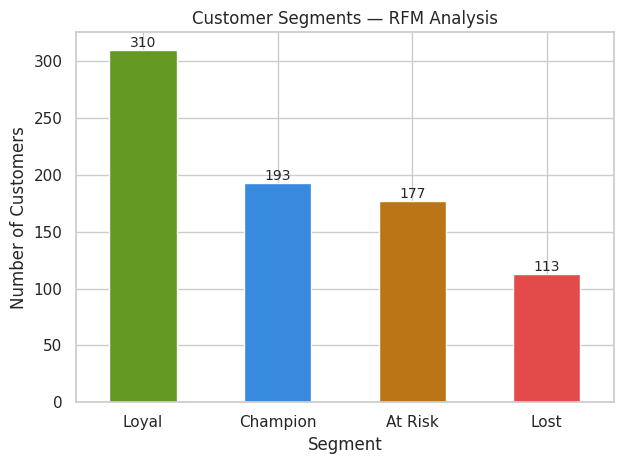

In [13]:
# Chart 1 — RFM segment distribution
seg_counts = rfm['segment'].value_counts()

ax = seg_counts.plot(kind='bar', 
                     color=['#639922', '#378ADD', '#BA7517', '#E24B4A'])
ax.set_title('Customer Segments — RFM Analysis')
ax.set_xlabel('Segment')
ax.set_ylabel('Number of Customers')
ax.tick_params(axis='x', rotation=0)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

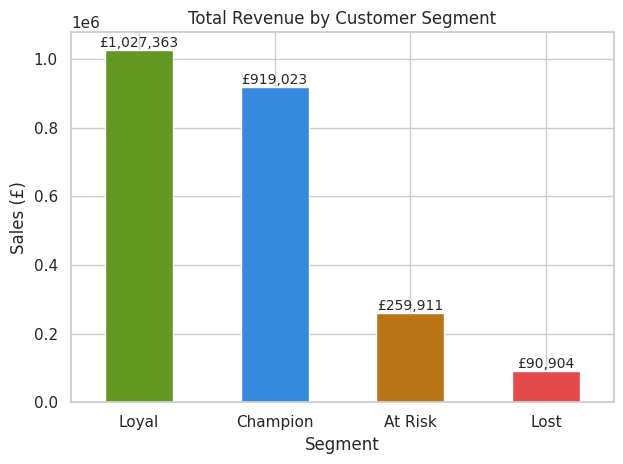

In [14]:
# Chart 2 — Revenue by segment
seg_revenue = df_rfm.groupby('segment')['Sales'].sum().sort_values(ascending=False)

ax = seg_revenue.plot(kind='bar',
                      color=['#639922', '#378ADD', '#BA7517', '#E24B4A'])
ax.set_title('Total Revenue by Customer Segment')
ax.set_xlabel('Segment')
ax.set_ylabel('Sales (£)')
ax.tick_params(axis='x', rotation=0)

for p in ax.patches:
    ax.annotate(f'£{p.get_height():,.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Key findings — Notebook 3
- 793 unique customers segmented into Champions (193), Loyal (310), At Risk (177), Lost (113)
- £350,814 (15.3% of total revenue) is at risk from disengaging customers
- High discount orders (>20%) average £-97 profit vs £49 for low discount orders
- T-test confirms this difference is statistically significant (p < 0.0001)